# Nettoyer les données récupérées

In [399]:
import pandas as pd
from datetime import datetime, timedelta

In [400]:
df_quotations = pd.read_csv("quotation.csv", sep ="\t")
df_articles = pd.read_csv("articles.csv", sep=",")



print(df_articles.shape)
print(df_quotations.shape)

(878, 3)
(61, 8)


In [401]:
df_articles.head()

,titre,date_texte,date
0,Pourquoi la nouvelle manoeuvre du Japon pour f...,Publié à 14:50,2026-05-03
1,DIRECT - Guerre au Moyen-Orient : l'Iran estim...,Publié à 09:09,2026-05-03
2,Guerre au Moyen-Orient : un responsable iranie...,Publié le 2 mai à 13:30,2026-05-02
3,VIDEO - La Chine veut faire de cette île un pe...,Publié le 2 mai à 12:00,2026-05-02
4,Trump présente la guerre avec l'Iran comme « t...,Publié le 2 mai à 08:57,2026-05-02


In [402]:
df_quotations.head()

,date,ouv,haut,bas,clot,vol,devise,Unnamed: 7
0,04/02/2026 00:00,8219.96,8298.41,8203.27,8262.16,4973,Pts,NaN
1,05/02/2026 00:00,8288.47,8312.68,8193.20,8238.17,4471,Pts,NaN
2,06/02/2026 00:00,8214.85,8287.92,8175.09,8273.84,4447,Pts,NaN
3,09/02/2026 00:00,8294.83,8323.28,8258.75,8323.28,3468,Pts,NaN
4,10/02/2026 00:00,8348.82,8369.71,8316.61,8327.88,4050,Pts,NaN


In [403]:
df_quotations = df_quotations.drop(columns=["Unnamed: 7"])
df_quotations.head()

,date,ouv,haut,bas,clot,vol,devise
0,04/02/2026 00:00,8219.96,8298.41,8203.27,8262.16,4973,Pts
1,05/02/2026 00:00,8288.47,8312.68,8193.20,8238.17,4471,Pts
2,06/02/2026 00:00,8214.85,8287.92,8175.09,8273.84,4447,Pts
3,09/02/2026 00:00,8294.83,8323.28,8258.75,8323.28,3468,Pts
4,10/02/2026 00:00,8348.82,8369.71,8316.61,8327.88,4050,Pts


In [404]:
#supprimer les artciles sans dates
df_articles = df_articles.dropna(subset=["date"])
# Convertir la date
df_articles["date"] = pd.to_datetime(df_articles["date"])
df_articles.head()

,titre,date_texte,date
0,Pourquoi la nouvelle manoeuvre du Japon pour f...,Publié à 14:50,2026-05-03
1,DIRECT - Guerre au Moyen-Orient : l'Iran estim...,Publié à 09:09,2026-05-03
2,Guerre au Moyen-Orient : un responsable iranie...,Publié le 2 mai à 13:30,2026-05-02
3,VIDEO - La Chine veut faire de cette île un pe...,Publié le 2 mai à 12:00,2026-05-02
4,Trump présente la guerre avec l'Iran comme « t...,Publié le 2 mai à 08:57,2026-05-02


In [405]:
#modification de la date dans quotations
df_quotations["date"] = pd.to_datetime(df_quotations["date"],dayfirst=True)
df_quotations = df_quotations.sort_values("date", ascending=False)

print(df_quotations.dtypes)
print(df_quotations.shape)
df_quotations.head()

date      datetime64[ns]
ouv              float64
haut             float64
bas              float64
clot             float64
vol                int64
devise            object
dtype: object
(61, 7)


,date,ouv,haut,bas,clot,vol,devise
60,2026-05-04,8122.10,8122.10,8085.58,8099.39,403,Pts
59,2026-04-30,7962.84,8115.08,7957.83,8114.84,5925,Pts
58,2026-04-29,8088.98,8110.62,8036.46,8072.13,3879,Pts
57,2026-04-28,8129.35,8172.89,8090.70,8104.09,3877,Pts
56,2026-04-27,8160.18,8214.63,8127.83,8141.92,3170,Pts


### Harmoniser les dates

In [406]:
# Filter data to the last 90 days
date_end   = pd.Timestamp(datetime.today().date())
date_start = date_end - timedelta(days=90)

df_quotations_filtered = df_quotations[(df_quotations["date"] >= date_start) & (df_quotations["date"] <= date_end)]
df_articles_filtered   = df_articles[(df_articles["date"] >= date_start) & (df_articles["date"] <= date_end)]

df_quotations_filtered
df_articles_filtered

,titre,date_texte,date
0,Pourquoi la nouvelle manoeuvre du Japon pour f...,Publié à 14:50,2026-05-03
1,DIRECT - Guerre au Moyen-Orient : l'Iran estim...,Publié à 09:09,2026-05-03
2,Guerre au Moyen-Orient : un responsable iranie...,Publié le 2 mai à 13:30,2026-05-02
3,VIDEO - La Chine veut faire de cette île un pe...,Publié le 2 mai à 12:00,2026-05-02
4,Trump présente la guerre avec l'Iran comme « t...,Publié le 2 mai à 08:57,2026-05-02
...,...,...,...
866,L'immigration légale aux Etats-Unis en chute l...,Publié le 3 févr. à 12:08,2026-02-03
867,"Gaz de combat, bases secrètes, arrestations ma...",Publié le 3 févr. à 12:07,2026-02-03
868,Droits de douane : les zones d'ombre que cache...,Publié le 3 févr. à 10:50,2026-02-03
869,L'Iran se prépare à des pourparlers sur le nuc...,Publié le 3 févr. à 07:58,2026-02-03


### Début du travail d'analyse : calcul et comparation

In [407]:
# Sort ascending BEFORE pct_change, otherwise the time direction is reversed
df_quotations_filtered = df_quotations_filtered.sort_values("date", ascending=True).copy()

# Calculate daily variation between closing prices
# pct_change() calcule (aujourd'hui - hier) / hier * 100
df_quotations_filtered["variation"] = df_quotations_filtered["clot"].pct_change() * 100
df_quotations_filtered["variation"] = df_quotations_filtered["variation"].round(2)

print(df_quotations_filtered[["date", "clot", "variation"]].head(10))

        date     clot  variation
0 2026-02-04  8262.16        NaN
1 2026-02-05  8238.17      -0.29
2 2026-02-06  8273.84       0.43
3 2026-02-09  8323.28       0.60
4 2026-02-10  8327.88       0.06
5 2026-02-11  8313.24      -0.18
6 2026-02-12  8340.56       0.33
7 2026-02-13  8311.74      -0.35
8 2026-02-16  8316.50       0.06
9 2026-02-17  8361.46       0.54


In [408]:
# Classify each article title as positive, negative or neutral based on keywords
bad = ["guerre", "crise", "chute", "tensions", "droits de douane", "inflation",
    "blocus", "frappes", "missiles", "conflit", "escalade", "sanctions",
    "déficit", "dettes", "emprunter", "limogé", "purge", "attentat",
    "tirs", "chaos", "effondrer", "menace", "ultimatum", "panique",
    "vulnérable", "déclin", "fragilisée", "décrochage", "choc pétrolier",
    "cessez-le-feu", "combats", "bombes", "drones", "armement", "pression",
    "recul", "fraude", "scandale", "menacé", "bloqué", "épuise",
    "dangereusement", "critique", "difficile", "choc", "indignation",
    "limogeage", "démantelé", "sabrer", "plonge", "surestimée",
    "inquiète", "alourdie", "échec", "retard"]

good = ["accord", "croissance", "reprise", "hausse", "optimisme",
    "soutien", "majorité", "victoire", "investissements", "boom",
    "réouverture", "liberté", "normalisation", "excédent", "soulagement",
    "réconciliation", "rapprochement", "libéré", "positif", "renoue",
    "décroche", "feu vert", "récompensés", "euphorie", "pragmatisme",
    "gagnante", "relance", "atouts", "fort"]

def classify_news(title):
    title = title.lower()
    if any(word in title for word in bad):
        return "negative"
    elif any(word in title for word in good):
        return "positive"
    else:
        return "neutral"

df_articles_filtered["trend"] = df_articles_filtered["titre"].apply(classify_news)
df_articles_filtered["trend"].value_counts()

C:\Users\ilham\AppData\Local\Temp\ipykernel_112300\3403171232.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_articles_filtered["trend"] = df_articles_filtered["titre"].apply(classify_news)


negative    514
neutral     291
positive     66
Name: trend, dtype: int64

In [409]:
# Count positive/negative/neutral articles per day
count_trend = df_articles_filtered.groupby(["date", "trend"])["titre"].count().unstack(fill_value=0).reset_index()
count_trend.columns.name = None
count_trend = count_trend.rename(columns={
    "negative": "nb_negative",
    "positive": "nb_positive",
    "neutral":  "nb_neutral"
})

In [410]:
# Count total articles per day
articles_by_day = df_articles_filtered.groupby("date")["titre"].count().reset_index()
articles_by_day.columns = ["date", "nb_articles"]
articles_by_day.head(10)

,date,nb_articles
0,2026-02-03,12
1,2026-02-04,12
2,2026-02-05,10
3,2026-02-06,7
4,2026-02-07,6
5,2026-02-08,7
6,2026-02-09,8
7,2026-02-10,9
8,2026-02-11,11
9,2026-02-12,11


In [411]:
# J-1 shift: shift article dates forward by 1 day
# Logic: articles published on day J influence prices on day J+1
articles_by_day_shift = articles_by_day.copy()
articles_by_day_shift["date"] = articles_by_day_shift["date"] + pd.Timedelta(days=1)

count_trend_shift = count_trend.copy()
count_trend_shift["date"] = count_trend_shift["date"] + pd.Timedelta(days=1)

# Merge prices with articles from the PREVIOUS day (J-1)
df_final = df_quotations_filtered.merge(articles_by_day_shift, on="date", how="left")
df_final["nb_articles"] = df_final["nb_articles"].fillna(0).astype(int)
df_final = df_final.merge(count_trend_shift, on="date", how="left")
df_final[["nb_negative", "nb_positive", "nb_neutral"]] = df_final[["nb_negative", "nb_positive", "nb_neutral"]].fillna(0).astype(int)

df_final.sort_values("date", ascending=False)

,date,ouv,haut,bas,clot,vol,devise,variation,nb_articles,nb_negative,nb_neutral,nb_positive
60,2026-05-04,8122.10,8122.10,8085.58,8099.39,403,Pts,-0.19,2,2,0,0
59,2026-04-30,7962.84,8115.08,7957.83,8114.84,5925,Pts,0.53,11,6,5,0
58,2026-04-29,8088.98,8110.62,8036.46,8072.13,3879,Pts,-0.39,6,5,1,0
57,2026-04-28,8129.35,8172.89,8090.70,8104.09,3877,Pts,-0.46,6,6,0,0
56,2026-04-27,8160.18,8214.63,8127.83,8141.92,3170,Pts,-0.19,7,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4,2026-02-10,8348.82,8369.71,8316.61,8327.88,4050,Pts,0.06,8,3,4,1
3,2026-02-09,8294.83,8323.28,8258.75,8323.28,3468,Pts,0.60,7,1,3,3
2,2026-02-06,8214.85,8287.92,8175.09,8273.84,4447,Pts,0.43,10,3,6,1
1,2026-02-05,8288.47,8312.68,8193.20,8238.17,4471,Pts,-0.29,12,5,5,2


### Comparaison finale : variation après actualité négative vs jours normaux

In [412]:
# Drop rows without variation (first day has no reference)
df_compare = df_final.dropna(subset=["variation"])

# identififation des jours avec ou bcp d'articles negatifs
# j'utilise un seuil dynamique qui est la médiane du nombre d'articles négatifs sur toutes la periode
#j'ai voulu le mettre en fixe mais ce n'était pas cohérent (comment je choisi le seuil ?)

level = df_compare["nb_negative"].median()
print(f"Seuil: {level} articles négatifs par jour")


negative_days = df_compare[df_compare["nb_negative"] > level]
calm_days     = df_compare[df_compare["nb_negative"] <= level]

after_negative = negative_days["variation"].abs().mean()
after_calm     = calm_days["variation"].abs().mean()

print(f"Nombre de jours avec bcp d'actualité négative : {len(negative_days)}")
print(f"Nombre de jours avec actualité calme          : {len(calm_days)}")
print()

print("Réponse à la problméatique de départ")
print(f"Variation moyenne du CAC40 après forte actualité négative : {after_negative:.2f}%")
print(f"Variation moyenne du CAC40 après actualité calme          : {after_calm:.2f}%")
print()

if after_negative > after_calm:
    diff = after_negative - after_calm
    print(f"Conclusion : Le CAC40 varie {diff:.2f}% de plus en valeur absolue après une actualité négative.")
else:
    diff = after_calm - after_negative
    print(f"Conclusion : Les actualités négatives ne provoquent pas de plus grande variation ({diff:.2f}% de moins).")

Seuil: 5.5 articles négatifs par jour
Nombre de jours avec bcp d'actualité négative : 30
Nombre de jours avec actualité calme          : 30

Réponse à la problméatique de départ
Variation moyenne du CAC40 après forte actualité négative : 0.97%
Variation moyenne du CAC40 après actualité calme          : 0.70%

Conclusion : Le CAC40 varie 0.27% de plus en valeur absolue après une actualité négative.


In [413]:
df_articles_filtered[df_articles_filtered["date"] == "2026-04-07"]["titre"]

233    Guerre au Moyen-Orient : la Russie et la Chine...
234    Retour des otages d'Iran : les efforts diploma...
235    Taxe sur les superprofits du gaz et du pétrole...
236    Le Canada envisage des droits de douane pour c...
237    « Epic Fury 2 » : Trump pousse à l'escalade, l...
238    « Je suis à votre service » : l'édifiant coup ...
239    « Le centre névralgique de l'internationale d'...
240    « Si la Russie cesse ses frappes, nous ferons ...
241    Taïwan : la direction du grand parti d'opposit...
242    DIRECT - Guerre au Moyen-Orient : Trump met fi...
243    « Une absorption sans annexion » : comment la ...
Name: titre, dtype: object

In [414]:
# Volatilité (amplitude)
print("Amplitude de variation")
print(f"Après actualité négative : {negative_days['variation'].abs().mean():.2f}%")
print(f"Après actualité calme    : {calm_days['variation'].abs().mean():.2f}%")

print()

# Direction (hausse ou baisse)
print("Direction de variation ")
print(f"Après actualité négative : {negative_days['variation'].mean():.2f}%")
print(f"Après actualité calme    : {calm_days['variation'].mean():.2f}%")

Amplitude de variation
Après actualité négative : 0.97%
Après actualité calme    : 0.70%

Direction de variation 
Après actualité négative : -0.27%
Après actualité calme    : 0.21%


In [415]:
# Export des articles avec la tendance classifiée
df_articles_filtered.to_csv("articles_with_trend.csv", index=False)
print("Fichier exporté : articles_with_trend.csv")

Fichier exporté : articles_with_trend.csv


In [416]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    negative_days["variation"].abs(),
    calm_days["variation"].abs(),
    equal_var=False
)

print(f"p-value = {p_value:.4f}")
if p_value < 0.05:
    print("Ok :Différence statistiquement significative — le résultat est fiable.")
else:
    print("prudence : Données à interpréter avec prudence.")

p-value = 0.2001
prudence : Données à interpréter avec prudence.


## Graphique

In [417]:
import matplotlib.pyplot as plt

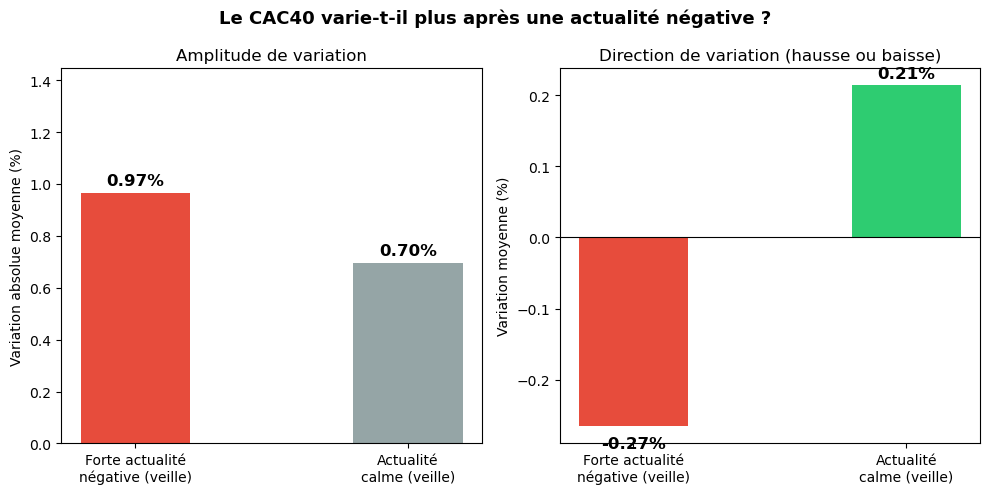

In [418]:
# creation de 2 graphique sur une meme ligne
fig, axes = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle("Le CAC40 varie-t-il plus après une actualité négative ?", fontsize=13, fontweight="bold")

##### graph 1 amplitude la de variation
ax1 = axes[0]
valeurs_amp = [after_negative, after_calm]
labels = ["Forte actualité\nnégative (veille)", "Actualité\ncalme (veille)"]
couleurs_amp = ["#e74c3c", "#95a5a6"]

ax1.bar(labels, valeurs_amp, color=couleurs_amp, width=0.4)
ax1.set_title("Amplitude de variation")
ax1.set_ylabel("Variation absolue moyenne (%)")
ax1.set_ylim(0, max(valeurs_amp) * 1.5)
for i, v in enumerate(valeurs_amp):
    ax1.text(i, v + 0.03, f"{v:.2f}%", ha="center", fontsize=12, fontweight="bold")

##### graph 2 : Direction de la variation (hausse ou baisse) 
ax2 = axes[1]
dir_neg = negative_days["variation"].mean()
dir_cal = calm_days["variation"].mean()
valeurs_dir = [dir_neg, dir_cal]

# Rouge si baisse, vert si hausse
couleurs_dir = ["#e74c3c" if v < 0 else "#2ecc71" for v in valeurs_dir]

ax2.bar(labels, valeurs_dir, color=couleurs_dir, width=0.4)
ax2.set_title("Direction de variation (hausse ou baisse)")
ax2.set_ylabel("Variation moyenne (%)")
ax2.axhline(0, color="black", linewidth=0.8)
for i, v in enumerate(valeurs_dir):
    offset = 0.01 if v >= 0 else -0.03
    ax2.text(i, v + offset, f"{v:.2f}%", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()
